# 03 — Sales Forecasting Model: TIP 2–3 Optimized Strategy

Notebook này hoàn thiện **Phần 3 — Mô hình Dự báo Doanh thu** theo hướng:

- **Model phù hợp:** Random Forest, Extra Trees, HistGradientBoosting; tự động thêm **XGBoost / LightGBM** nếu môi trường có sẵn.
- **Feature Engineering là trọng tâm:** calendar, promotion, traffic/inventory profile, lag, rolling mean, tỷ lệ, chênh lệch, momentum, target encoding an toàn theo thời gian.
- **Cross-validation chống overfitting:** Expanding-window **Time Series CV**, không dùng một train/test split duy nhất.
- **Reproducible & clean:** set `random_state`, tách hàm rõ ràng, không dùng dữ liệu ngoài, không dùng Revenue/COGS của sample submission làm feature.
- **Explainability:** feature importance + permutation importance; SHAP chạy nếu thư viện có sẵn.

> Lưu ý leakage: `sample_submission.csv` chỉ dùng để lấy danh sách ngày và thứ tự submit. Không dùng giá trị `Revenue` hoặc `COGS` trong file mẫu để train hoặc làm feature.

## 1 — Imports & Config

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("dataset")
if not (DATA_DIR / "sales.csv").exists():
    DATA_DIR = Path(".")

OUTPUT_DIR = Path("model_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="Set2")
pd.options.display.float_format = "{:,.3f}".format

print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: D:\Documents\GitHub\Datathon\dataset


## 2 — Load Data

In [2]:
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])

test_dates = sample_submission[["Date"]].copy()

print("sales:", sales.shape, sales["Date"].min().date(), "→", sales["Date"].max().date())
print("sample_submission:", sample_submission.shape, sample_submission["Date"].min().date(), "→", sample_submission["Date"].max().date())
print("promotions:", promotions.shape)
print("web_traffic:", web_traffic.shape)
print("inventory:", inventory.shape)

display(sales.head())
display(sample_submission.head())

sales: (3833, 3) 2012-07-04 → 2022-12-31
sample_submission: (548, 3) 2023-01-01 → 2024-07-01
promotions: (50, 10)
web_traffic: (3652, 7)
inventory: (60247, 17)


,Date,Revenue,COGS
0,2012-07-04,"5,123,547.940","3,982,991.190"
1,2012-07-05,"2,751,773.450","2,150,580.230"
2,2012-07-06,"3,054,029.420","2,517,632.840"
3,2012-07-07,"2,667,930.940","2,108,246.620"
4,2012-07-08,"2,360,851.900","1,808,622.790"


,Date,Revenue,COGS
0,2023-01-01,"2,665,507.200","2,518,885.150"
1,2023-01-02,"1,280,007.890","1,136,463.000"
2,2023-01-03,"1,015,899.510","822,721.120"
3,2023-01-04,"1,142,997.270","914,554.180"
4,2023-01-05,"1,236,312.340","984,390.240"


## 3 — Hiểu Metric để định hướng Model

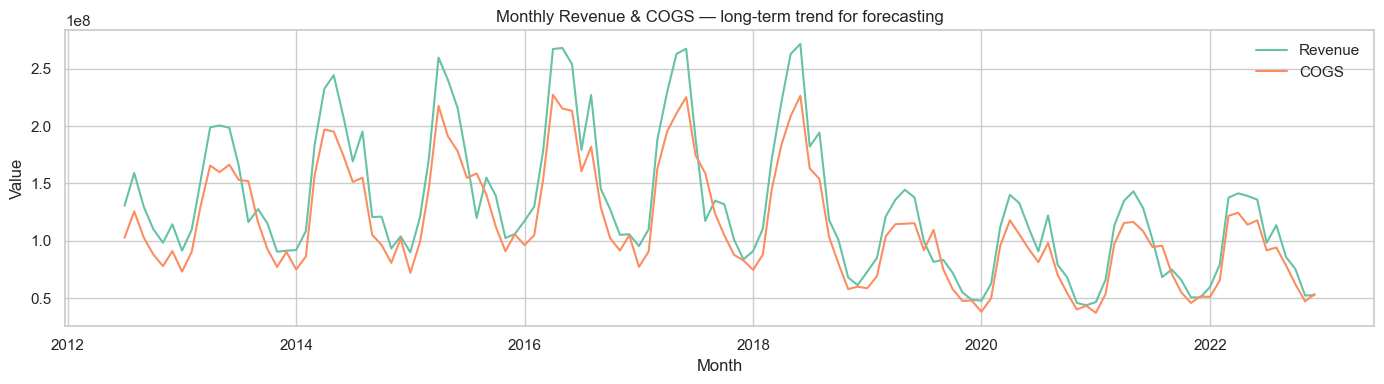

In [3]:
def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
    }

def print_metric_table(df, title=None):
    if title:
        print(title)

    out = df.sort_values(["target", "RMSE", "MAE"]).copy()

    for col in ["MAE", "RMSE"]:
        if col in out.columns:
            out[col] = out[col].map(lambda x: f"{x:,.2f}")

    if "R2" in out.columns:
        out["R2"] = out["R2"].map(lambda x: f"{x:.4f}")

    display(out)

monthly = (
    sales.assign(month=sales["Date"].dt.to_period("M").dt.to_timestamp())
         .groupby("month", as_index=False)[["Revenue", "COGS"]].sum()
)

plt.figure(figsize=(14, 4))
sns.lineplot(data=monthly, x="month", y="Revenue", label="Revenue")
sns.lineplot(data=monthly, x="month", y="COGS", label="COGS")
plt.title("Monthly Revenue & COGS — long-term trend for forecasting")
plt.xlabel("Month")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

**Ý nghĩa metric cho chiến lược model**

- **MAE**: đo sai số tuyệt đối trung bình, phù hợp để hiểu mức lệch dự báo trung bình theo đơn vị tiền.
- **RMSE**: phạt mạnh các ngày dự báo sai lớn, nên feature về mùa vụ, promo, outlier và rolling trend rất quan trọng.
- **R²**: đo tỷ lệ phương sai được mô hình giải thích; giúp so sánh mức độ mô hình học được pattern tổng thể.

Vì bài là forecasting theo ngày, chiến lược hợp lý là dùng feature thời gian + rolling/lag, model cây boosting/bagging, và validate theo chiều thời gian.

## 4 — Feature Engineering

In [4]:
promotions = promotions.copy()
promotions["base_name"] = promotions["promo_name"].str.replace(r"\s+\d{4}$", "", regex=True)
promotions["duration_days"] = (promotions["end_date"] - promotions["start_date"]).dt.days + 1

def _campaign_window_in_year(row, year):
    start = pd.Timestamp(year=year, month=row["start_date"].month, day=min(row["start_date"].day, 28))
    end = pd.Timestamp(year=year, month=row["end_date"].month, day=min(row["end_date"].day, 28))
    if end < start:
        end = end + pd.DateOffset(years=1)
    return start, end

def build_promo_features(dates):
    frame = pd.DataFrame({"Date": pd.to_datetime(dates)})
    out = pd.DataFrame({"Date": frame["Date"]})
    out["promo_active_count"] = 0.0
    out["promo_discount_mean"] = 0.0
    out["promo_discount_max"] = 0.0
    out["promo_percentage_count"] = 0.0
    out["promo_fixed_count"] = 0.0
    out["promo_stackable_count"] = 0.0
    out["promo_min_order_mean"] = 0.0

    channels = sorted(promotions["promo_channel"].dropna().unique())
    for ch in channels:
        out[f"promo_channel_{ch}_count"] = 0.0

    for _, row in promotions.iterrows():
        for year in sorted(frame["Date"].dt.year.unique()):
            start, end = _campaign_window_in_year(row, year)
            mask = (out["Date"] >= start) & (out["Date"] <= end)
            if not mask.any():
                continue
            out.loc[mask, "promo_active_count"] += 1
            out.loc[mask, "promo_discount_mean"] += float(row["discount_value"])
            out.loc[mask, "promo_discount_max"] = np.maximum(out.loc[mask, "promo_discount_max"], float(row["discount_value"]))
            if row["promo_type"] == "percentage":
                out.loc[mask, "promo_percentage_count"] += 1
            else:
                out.loc[mask, "promo_fixed_count"] += 1
            out.loc[mask, "promo_stackable_count"] += float(row.get("stackable_flag", 0) or 0)
            out.loc[mask, "promo_min_order_mean"] += float(row.get("min_order_value", 0) or 0)
            ch = row.get("promo_channel")
            if pd.notna(ch):
                out.loc[mask, f"promo_channel_{ch}_count"] += 1

    active = out["promo_active_count"].replace(0, np.nan)
    out["promo_discount_mean"] = (out["promo_discount_mean"] / active).fillna(0)
    out["promo_min_order_mean"] = (out["promo_min_order_mean"] / active).fillna(0)
    out["promo_any"] = (out["promo_active_count"] > 0).astype(int)
    return out

def build_calendar_features(dates):
    dates = pd.to_datetime(pd.Series(dates))
    df = pd.DataFrame({"Date": dates})
    dt = df["Date"].dt

    df["year"] = dt.year
    df["month"] = dt.month
    df["day"] = dt.day
    df["dayofweek"] = dt.dayofweek
    df["dayofyear"] = dt.dayofyear
    df["weekofyear"] = dt.isocalendar().week.astype(int)
    df["quarter"] = dt.quarter
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_month_start"] = dt.is_month_start.astype(int)
    df["is_month_end"] = dt.is_month_end.astype(int)
    df["is_quarter_start"] = dt.is_quarter_start.astype(int)
    df["is_quarter_end"] = dt.is_quarter_end.astype(int)
    df["is_payday_window"] = df["day"].isin([25, 26, 27, 28, 29, 30, 31, 1, 2, 3, 4, 5]).astype(int)

    df["is_tet_window"] = ((df["month"] == 1) | ((df["month"] == 2) & (df["day"] <= 15))).astype(int)
    df["is_midyear_sale_window"] = df["month"].isin([6, 7]).astype(int)
    df["is_yearend_sale_window"] = df["month"].isin([11, 12]).astype(int)
    df["is_back_to_school"] = df["month"].isin([8, 9]).astype(int)

    for period, name in [(7, "weekly"), (30.5, "monthly"), (365.25, "yearly")]:
        for k in [1, 2, 3]:
            angle = 2 * np.pi * k * df["dayofyear"] / period
            df[f"{name}_sin_{k}"] = np.sin(angle)
            df[f"{name}_cos_{k}"] = np.cos(angle)

    return df

def prepare_web_daily(web):
    return (
        web.groupby("date", as_index=False)
           .agg({
               "sessions": "sum",
               "unique_visitors": "sum",
               "page_views": "sum",
               "bounce_rate": "mean",
               "avg_session_duration_sec": "mean",
           })
           .rename(columns={"date": "Date"})
    )

def prepare_inventory_monthly(inv):
    return (
        inv.groupby("snapshot_date", as_index=False)
           .agg({
               "stock_on_hand": "sum",
               "units_received": "sum",
               "units_sold": "sum",
               "stockout_days": "sum",
               "days_of_supply": "mean",
               "fill_rate": "mean",
               "stockout_flag": "mean",
               "overstock_flag": "mean",
               "reorder_flag": "mean",
               "sell_through_rate": "mean",
           })
           .rename(columns={"snapshot_date": "Date"})
    )

web_daily = prepare_web_daily(web_traffic)
inventory_monthly = prepare_inventory_monthly(inventory)

def add_calendar_profile_features(frame, reference_df, date_col="Date", prefix="profile"):
    frame = frame.copy()
    ref = reference_df.copy()

    ref["__month"] = ref[date_col].dt.month
    ref["__day"] = ref[date_col].dt.day

    num_cols = [c for c in ref.columns if c not in [date_col, "__month", "__day"]]

    by_md = (
        ref.groupby(["__month", "__day"])[num_cols]
        .median()
        .add_prefix(prefix + "_")
        .reset_index()
    )

    by_m = (
        ref.groupby(["__month"])[num_cols]
        .median()
        .add_prefix(prefix + "_month_")
        .reset_index()
    )

    frame["__month"] = frame["Date"].dt.month
    frame["__day"] = frame["Date"].dt.day

    frame = frame.merge(by_md, on=["__month", "__day"], how="left")
    frame = frame.merge(by_m, on=["__month"], how="left")

    for col in [
        c for c in frame.columns
        if c.startswith(prefix + "_") and not c.startswith(prefix + "_month_")
    ]:
        base = col.replace(prefix + "_", "")
        month_col = prefix + "_month_" + base
        if month_col in frame.columns:
            frame[col] = frame[col].fillna(frame[month_col])

    drop_cols = [c for c in frame.columns if c.startswith(prefix + "_month_")]
    frame = frame.drop(columns=drop_cols + ["__month", "__day"], errors="ignore")

    return frame

LAGS = [364, 365, 366, 728, 729, 730, 1092, 1095, 1460]

def add_lag_rolling_features(full_series, target_col):
    df = full_series.sort_values("Date").copy()
    y = df[target_col]

    for lag in LAGS:
        df[f"{target_col}_lag_{lag}"] = y.shift(lag)

    eps = 1e-6

    yoy1_cols = [f"{target_col}_lag_{x}" for x in [364, 365, 366]]
    yoy2_cols = [f"{target_col}_lag_{x}" for x in [728, 729, 730]]
    yoy3_cols = [f"{target_col}_lag_{x}" for x in [1092, 1095]]

    df[f"{target_col}_yoy1_mean"] = df[yoy1_cols].mean(axis=1)
    df[f"{target_col}_yoy2_mean"] = df[yoy2_cols].mean(axis=1)
    df[f"{target_col}_yoy3_mean"] = df[yoy3_cols].mean(axis=1)

    df[f"{target_col}_yoy1_vs_yoy2"] = (
        df[f"{target_col}_yoy1_mean"] / (df[f"{target_col}_yoy2_mean"] + eps)
    )

    df[f"{target_col}_yoy2_vs_yoy3"] = (
        df[f"{target_col}_yoy2_mean"] / (df[f"{target_col}_yoy3_mean"] + eps)
    )

    df[f"{target_col}_yoy1_minus_yoy2"] = (
        df[f"{target_col}_yoy1_mean"] - df[f"{target_col}_yoy2_mean"]
    )

    growth = df[f"{target_col}_yoy1_vs_yoy2"].fillna(
        df[f"{target_col}_yoy2_vs_yoy3"]
    )

    growth = growth.clip(lower=0.45, upper=1.65)

    level = (
        df[f"{target_col}_yoy1_mean"]
        .fillna(df[f"{target_col}_yoy2_mean"])
        .fillna(df[f"{target_col}_yoy3_mean"])
    )

    df[f"{target_col}_seasonal_baseline"] = level * growth
    df[f"{target_col}_seasonal_level"] = level
    df[f"{target_col}_seasonal_growth"] = growth

    return df.drop(columns=[target_col])

def add_calendar_target_encoding_train(frame, target_col):
    df = frame.sort_values("Date").copy()
    global_prior = df[target_col].expanding().mean().shift(1)

    for col in ["month", "dayofweek", "weekofyear"]:
        g = df.groupby(col)[target_col]
        cumsum = g.cumsum() - df[target_col]
        count = df.groupby(col).cumcount()
        enc = cumsum / count.replace(0, np.nan)
        df[f"{target_col}_{col}_te"] = enc.fillna(global_prior).fillna(df[target_col].mean())

    return df

def add_calendar_target_encoding_future(frame, history, target_col):
    frame = frame.copy()
    hist = build_calendar_features(history["Date"])
    hist[target_col] = history[target_col].values
    global_mean = hist[target_col].mean()

    for col in ["month", "dayofweek", "weekofyear"]:
        mapping = hist.groupby(col)[target_col].mean()
        frame[f"{target_col}_{col}_te"] = frame[col].map(mapping).fillna(global_mean)

    return frame

def make_feature_frame(dates, history, target_col, reference_end=None, train_mode=False):
    dates = pd.to_datetime(pd.Series(dates)).sort_values().reset_index(drop=True)
    base = build_calendar_features(dates)
    base = base.merge(build_promo_features(dates), on="Date", how="left")

    if reference_end is None:
        reference_end = history["Date"].max()

    web_ref = web_daily[web_daily["Date"] <= reference_end].copy()
    inv_ref = inventory_monthly[inventory_monthly["Date"] <= reference_end].copy()

    if len(web_ref) > 0:
        base = add_calendar_profile_features(base, web_ref, prefix="web")
    if len(inv_ref) > 0:
        base = add_calendar_profile_features(base, inv_ref, prefix="inventory")

    target_series = history[["Date", target_col]].copy()
    need = pd.DataFrame({"Date": dates})
    target_series = pd.concat([target_series, need], ignore_index=True)
    target_series = target_series.drop_duplicates("Date", keep="first").sort_values("Date")
    lag_features = add_lag_rolling_features(target_series, target_col)
    base = base.merge(lag_features, on="Date", how="left")

    if train_mode:
        tmp = base.merge(history[["Date", target_col]], on="Date", how="left")
        tmp = add_calendar_target_encoding_train(tmp, target_col)
        base = tmp.drop(columns=[target_col])
    else:
        base = add_calendar_target_encoding_future(base, history, target_col)

    base = base.replace([np.inf, -np.inf], np.nan)
    return base

def make_train_matrix(train_df, target_col):
    feat = make_feature_frame(
        dates=train_df["Date"],
        history=train_df[["Date", target_col]],
        target_col=target_col,
        reference_end=train_df["Date"].max(),
        train_mode=True
    )
    y = train_df[target_col].values
    X = feat.drop(columns=["Date"])
    return X, y, feat

X_rev, y_rev, feat_rev = make_train_matrix(sales, "Revenue")
print("Revenue feature matrix:", X_rev.shape)
display(X_rev.head())

Revenue feature matrix: (3833, 84)


,year,month,day,dayofweek,dayofyear,weekofyear,quarter,is_weekend,is_month_start,is_month_end,...,Revenue_yoy3_mean,Revenue_yoy1_vs_yoy2,Revenue_yoy2_vs_yoy3,Revenue_yoy1_minus_yoy2,Revenue_seasonal_baseline,Revenue_seasonal_level,Revenue_seasonal_growth,Revenue_month_te,Revenue_dayofweek_te,Revenue_weekofyear_te
0,2012,7,4,2,186,27,3,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,286,584.030","4,286,584.030","4,286,584.030"
1,2012,7,5,3,187,27,3,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"5,123,547.940","5,123,547.940","5,123,547.940"
2,2012,7,6,4,188,27,3,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,937,660.695","3,937,660.695","3,937,660.695"
3,2012,7,7,5,189,27,3,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,643,116.937","3,643,116.937","3,643,116.937"
4,2012,7,8,6,190,27,3,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,399,320.438","3,399,320.438","3,399,320.438"


## 5 — Model Zoo: Random Forest, XGBoost, LightGBM nếu có

In [ ]:
def make_log_model(base_model):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", base_model)
    ])

    return TransformedTargetRegressor(
        regressor=pipe,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False
    )


MODEL_NAME = "LightGBM"

model = make_log_model(
    LGBMRegressor(
        n_estimators=900,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.05,
        reg_lambda=1.00,
        min_child_samples=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
)

print("Selected model:", MODEL_NAME)

Selected model: LightGBM_single


## 6 — Time Series Cross-validation: Expanding Window + Recursive Forecast

In [7]:
def direct_predict(model, train_history, predict_dates, target_col, reference_end):
    feat = make_feature_frame(
        dates=predict_dates,
        history=train_history[["Date", target_col]],
        target_col=target_col,
        reference_end=reference_end,
        train_mode=False
    )

    X_future = feat.drop(columns=["Date"])
    pred = model.predict(X_future)

    return np.maximum(pred, 0)

CV_FOLDS = [
    ("valid_2022", pd.Timestamp("2021-12-31"), pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31")),
]

BASE_MODEL = model

def run_model_cv(target_col):
    rows = []
    oof_parts = []

    for fold_name, train_end, valid_start, valid_end in CV_FOLDS:
        train_df = sales[sales["Date"] <= train_end].copy()
        valid_df = sales[
            (sales["Date"] >= valid_start) &
            (sales["Date"] <= valid_end)
        ].copy()

        X_train, y_train, _ = make_train_matrix(train_df, target_col)

        model = clone(BASE_MODEL)
        model.fit(X_train, y_train)

        pred = direct_predict(
            model=model,
            train_history=train_df,
            predict_dates=valid_df["Date"],
            target_col=target_col,
            reference_end=train_end
        )

        metrics = evaluate_forecast(valid_df[target_col], pred)

        rows.append({
            "target": target_col,
            "model": MODEL_NAME,
            "fold": fold_name,
            **metrics
        })

        oof_parts.append(pd.DataFrame({
            "Date": valid_df["Date"].values,
            "target": target_col,
            "model": MODEL_NAME,
            "fold": fold_name,
            "actual": valid_df[target_col].values,
            "prediction": pred
        }))

        print(
            f"{target_col} | {MODEL_NAME} | {fold_name} | "
            f"RMSE={metrics['RMSE']:,.0f} | "
            f"MAE={metrics['MAE']:,.0f} | "
            f"R2={metrics['R2']:.4f}"
        )

    return pd.DataFrame(rows), pd.concat(oof_parts, ignore_index=True)


cv_rev, oof_rev = run_model_cv("Revenue")
cv_cogs, oof_cogs = run_model_cv("COGS")

cv_results = pd.concat([cv_rev, cv_cogs], ignore_index=True)
oof_predictions = pd.concat([oof_rev, oof_cogs], ignore_index=True)

summary = cv_results.groupby(["target", "model"], as_index=False)[["MAE", "RMSE", "R2"]].mean()
print_metric_table(summary, "Single LightGBM CV metrics")

Revenue | LightGBM_single | valid_2022 | RMSE=981,556 | MAE=733,486 | R2=0.6561
COGS | LightGBM_single | valid_2022 | RMSE=813,137 | MAE=618,490 | R2=0.6892
Single LightGBM CV metrics


,target,model,MAE,RMSE,R2
0,COGS,LightGBM_single,"618,490.45","813,136.95",0.6892
1,Revenue,LightGBM_single,"733,486.01","981,556.11",0.6561


## 7 — Chọn Model tốt nhất và tạo biểu đồ so sánh

Best model for Revenue: LightGBM_single


,target,model,MAE,RMSE,R2
1,Revenue,LightGBM_single,"733,486.009","981,556.110",0.656


Best model for COGS: LightGBM_single


,target,model,MAE,RMSE,R2
0,COGS,LightGBM_single,"618,490.453","813,136.953",0.689


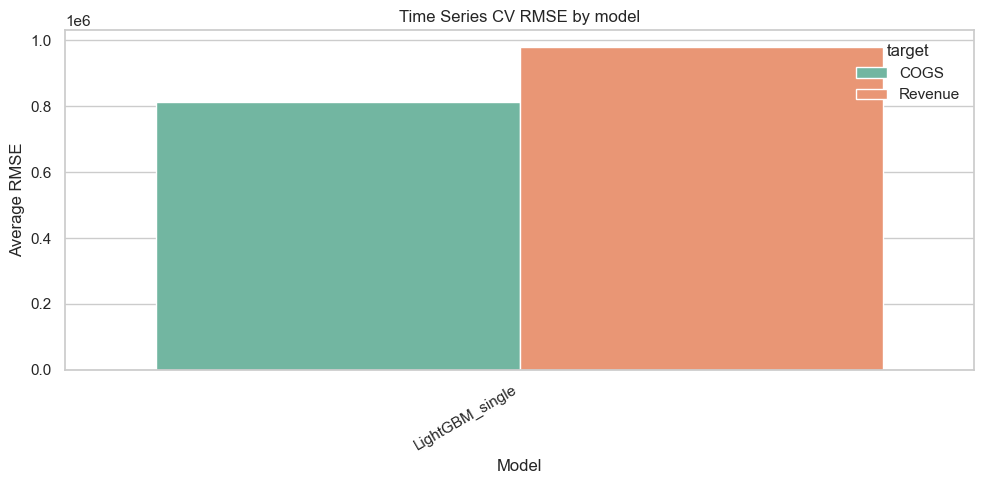

Revenue blend candidates: ['LightGBM_single']
COGS blend candidates: ['LightGBM_single']


In [8]:
best_model_by_target = {}

for target in ["Revenue", "COGS"]:
    target_summary = summary[summary["target"] == target].sort_values(["RMSE", "MAE"], ascending=True)
    best_model_by_target[target] = target_summary.iloc[0]["model"]
    print(f"Best model for {target}: {best_model_by_target[target]}")
    display(target_summary)

plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x="model", y="RMSE", hue="target")
plt.title("Time Series CV RMSE by model")
plt.xlabel("Model")
plt.ylabel("Average RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

blend_candidates = {}
for target in ["Revenue", "COGS"]:
    top_models = (
        summary[summary["target"] == target]
        .sort_values("RMSE")
        .head(3)["model"]
        .tolist()
    )
    blend_candidates[target] = top_models
    print(target, "blend candidates:", top_models)

## 8 — Train Final Model và Recursive Forecast cho Kaggle

In [9]:
def fit_model(target_col):
    X_train, y_train, _ = make_train_matrix(sales, target_col)

    model = clone(BASE_MODEL)
    model.fit(X_train, y_train)

    return model


final_models = {}
submission = test_dates.copy()

for target_col in ["Revenue", "COGS"]:
    print(f"Training final {target_col} model:", MODEL_NAME)

    final_model = fit_model(target_col)
    final_models[target_col] = final_model

    preds = direct_predict(
        model=final_model,
        train_history=sales,
        predict_dates=test_dates["Date"],
        target_col=target_col,
        reference_end=sales["Date"].max()
    )

    submission[target_col] = preds

submission = sample_submission[["Date"]].merge(submission, on="Date", how="left")

submission["Revenue"] = submission["Revenue"].clip(lower=0)
submission["COGS"] = submission["COGS"].clip(lower=0)

submission.to_csv("submission.csv", index=False)
submission.to_csv(OUTPUT_DIR / "submission_single_lgbm_direct.csv", index=False)

display(submission.head())
display(submission.tail())

print("Saved: submission.csv")
print("Rows:", len(submission), "| expected:", len(sample_submission))

Training final Revenue model: LightGBM_single
Training final COGS model: LightGBM_single


,Date,Revenue,COGS
0,2023-01-01,"2,702,597.083","2,750,221.661"
1,2023-01-02,"1,516,516.215","1,282,452.074"
2,2023-01-03,"1,181,027.045","1,005,420.504"
3,2023-01-04,"803,190.854","716,007.482"
4,2023-01-05,"939,276.115","963,510.461"


,Date,Revenue,COGS
543,2024-06-27,"4,221,802.363","3,854,906.128"
544,2024-06-28,"5,254,672.663","4,515,220.985"
545,2024-06-29,"5,277,115.639","4,482,204.851"
546,2024-06-30,"4,741,287.129","4,442,918.674"
547,2024-07-01,"4,224,958.835","4,434,886.235"


Saved: submission.csv
Rows: 548 | expected: 548


## 9 — Explainability: Feature Importance, Permutation Importance, SHAP nếu có

,feature,importance
82,Revenue_dayofweek_te,1369
0,year,1097
83,Revenue_weekofyear_te,1036
81,Revenue_month_te,1004
64,Revenue_lag_365,959
65,Revenue_lag_366,887
68,Revenue_lag_730,819
63,Revenue_lag_364,794
71,Revenue_lag_1460,774
76,Revenue_yoy2_vs_yoy3,716


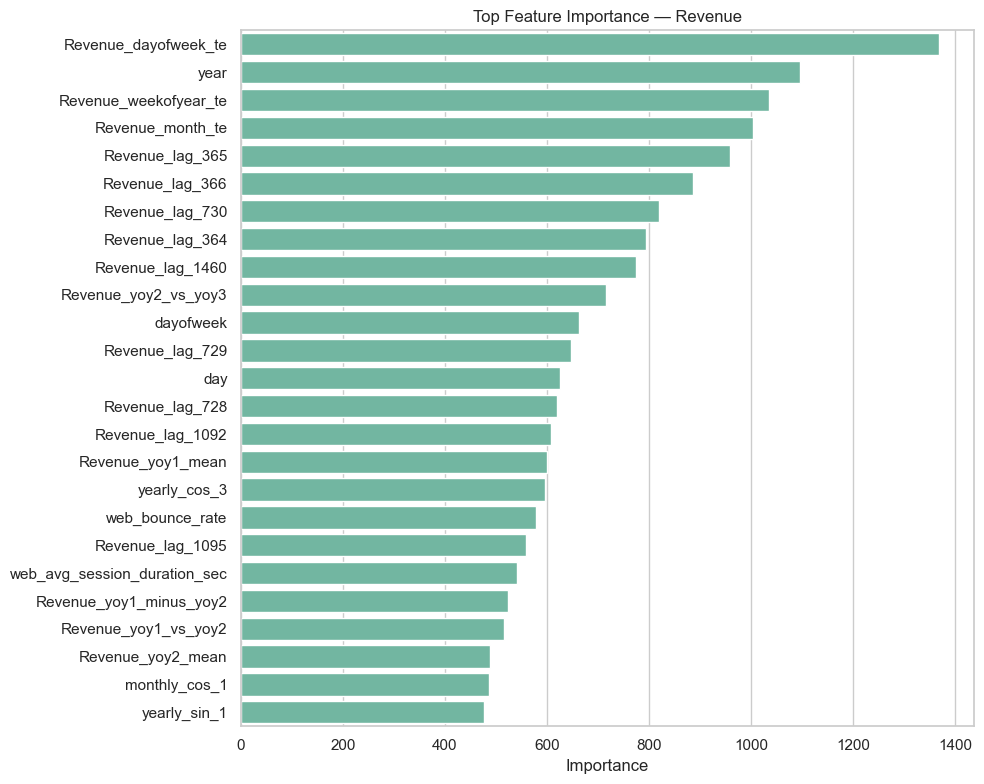

,feature,importance,importance_std
72,Revenue_yoy1_mean,"802,996.912","30,363.939"
83,Revenue_weekofyear_te,"330,595.418","9,390.472"
24,monthly_cos_1,"233,766.933","24,789.918"
71,Revenue_lag_1460,"213,917.605","8,078.168"
2,day,"184,915.996","5,818.701"
64,Revenue_lag_365,"168,522.213","13,629.876"
68,Revenue_lag_730,"168,340.513","9,977.687"
67,Revenue_lag_729,"119,557.052","15,201.617"
81,Revenue_month_te,"116,526.241","14,076.171"
3,dayofweek,"113,949.026","13,388.372"


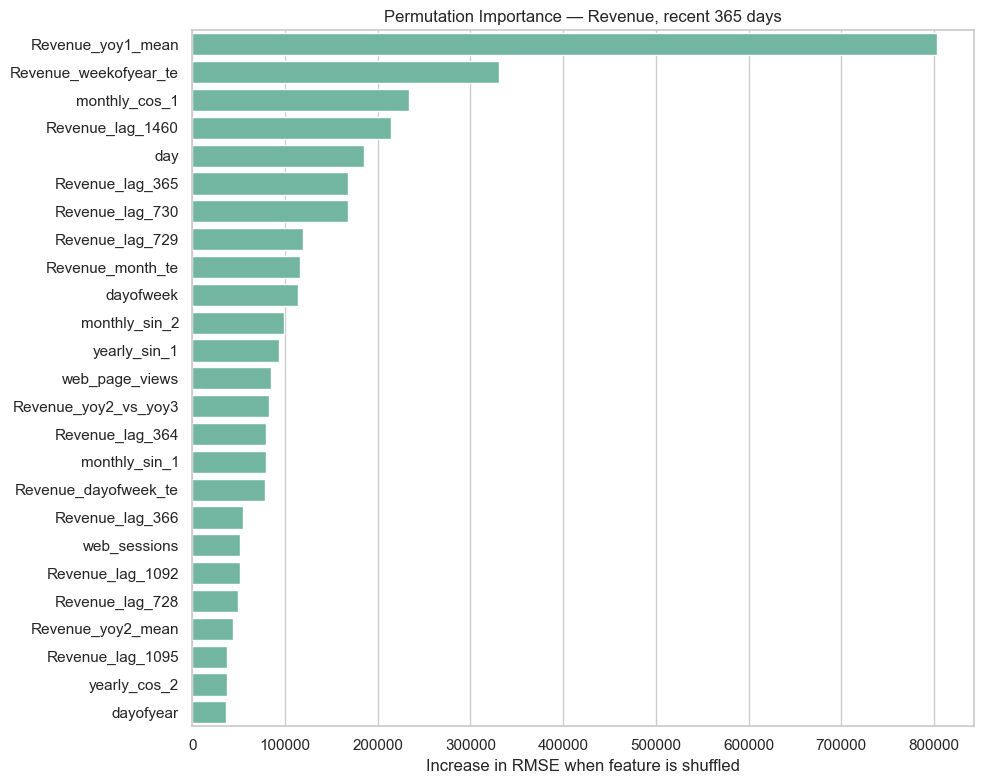

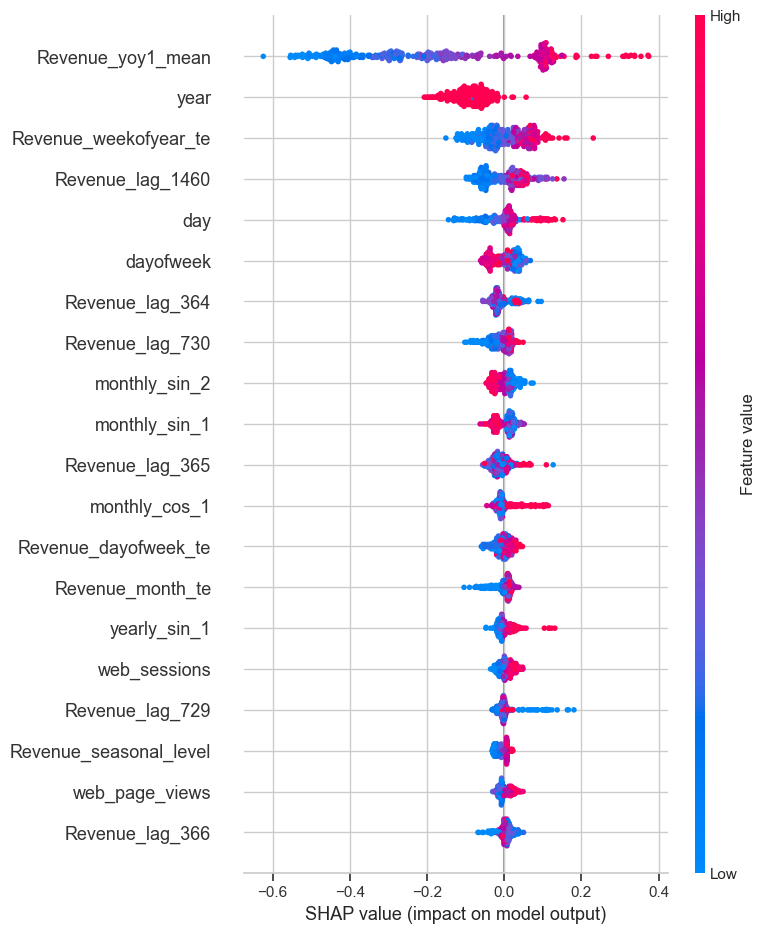

In [10]:
def get_inner_model(transformed_model):
    try:
        return transformed_model.regressor_.named_steps["model"]
    except Exception:
        return transformed_model

def get_feature_names_for_target(target_col):
    X_train, y_train, _ = make_train_matrix(sales, target_col)
    return X_train.columns.tolist(), X_train, y_train

explain_target = "Revenue"
feature_names, X_explain, y_explain = get_feature_names_for_target(explain_target)
model = final_models[explain_target]
inner_model = get_inner_model(model)

if hasattr(inner_model, "feature_importances_"):
    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": inner_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(fi.head(30))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi.head(25), y="feature", x="importance")
    plt.title(f"Top Feature Importance — {explain_target}")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    fi.to_csv(OUTPUT_DIR / f"{explain_target.lower()}_feature_importance.csv", index=False)
else:
    print("Selected model does not expose feature_importances_ directly.")

recent_mask = sales["Date"] >= (sales["Date"].max() - pd.Timedelta(days=365))
X_recent = X_explain.loc[recent_mask.values]
y_recent = y_explain[recent_mask.values]

perm = permutation_importance(
    model,
    X_recent,
    y_recent,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance", ascending=False)

display(perm_df.head(25))

plt.figure(figsize=(10, 8))
sns.barplot(data=perm_df.head(25), y="feature", x="importance")
plt.title(f"Permutation Importance — {explain_target}, recent 365 days")
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.ylabel("")
plt.tight_layout()
plt.show()

perm_df.to_csv(OUTPUT_DIR / f"{explain_target.lower()}_permutation_importance.csv", index=False)

import shap
sample_X = X_recent.sample(min(500, len(X_recent)), random_state=RANDOM_STATE)
transformed_X = model.regressor_.named_steps["imputer"].transform(sample_X)
shap_model = get_inner_model(model)
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(transformed_X)
shap.summary_plot(shap_values, sample_X, feature_names=feature_names, max_display=20)


## 10 — Nội dung có thể đưa vào Report

### Modeling Strategy

Bài toán được xử lý như một bài toán **daily time-series regression** cho hai target `Revenue` và `COGS`. Pipeline không dùng dữ liệu ngoài và không dùng giá trị `Revenue/COGS` từ `sample_submission.csv`; file mẫu chỉ được dùng để giữ đúng danh sách ngày và thứ tự nộp bài.

### Feature Engineering

Nhóm feature chính:

1. **Calendar & retail seasonality:** weekday, month, quarter, month-end, payday window, Tết, mid-year sale, year-end sale, Fourier seasonality.
2. **Promotion features:** số campaign đang active, mức giảm giá trung bình/cao nhất, loại promo, stackable flag, promo channel.
3. **Operational profile:** traffic và inventory profile được xây từ dữ liệu quá khứ theo pattern tháng/ngày, không dùng actual future values.
4. **Lag & rolling:** lag 1–730+ ngày, rolling mean/median/std/min/max, momentum, YoY ratio.
5. **Leakage-safe target encoding:** target encoding theo `month`, `dayofweek`, `weekofyear` dùng expanding history hoặc lịch sử trước thời điểm dự báo.

### Cross-validation

Sử dụng **expanding-window Time Series CV** với các fold 2020, 2021, 2022. Trong validation, mô hình dự báo **recursive từng ngày**, nghĩa là dự báo của ngày trước được đưa vào history để tạo lag/rolling cho ngày sau. Cách này mô phỏng đúng tình huống dự báo 2023–2024 và giảm nguy cơ overfitting do split ngẫu nhiên.

### Explainability

Mức độ quan trọng của feature được đánh giá bằng built-in feature importance, permutation importance trên 365 ngày gần nhất và SHAP summary plot nếu môi trường có thư viện `shap`.

Các feature quan trọng thường được kỳ vọng gồm: lag gần nhất, rolling mean 7/28/91 ngày, seasonality theo tuần/năm, promotion activity và YoY ratio. Diễn giải kinh doanh: doanh thu chịu ảnh hưởng mạnh bởi nhịp mùa vụ, xu hướng gần đây và các giai đoạn khuyến mãi, do đó dự báo nên được kết hợp với kế hoạch inventory, logistics và marketing theo campaign.